In [3]:
from symbol_estimator import *
from symbol_regression import *
from pde_data_generator import * 
from psiop import *

Data generation


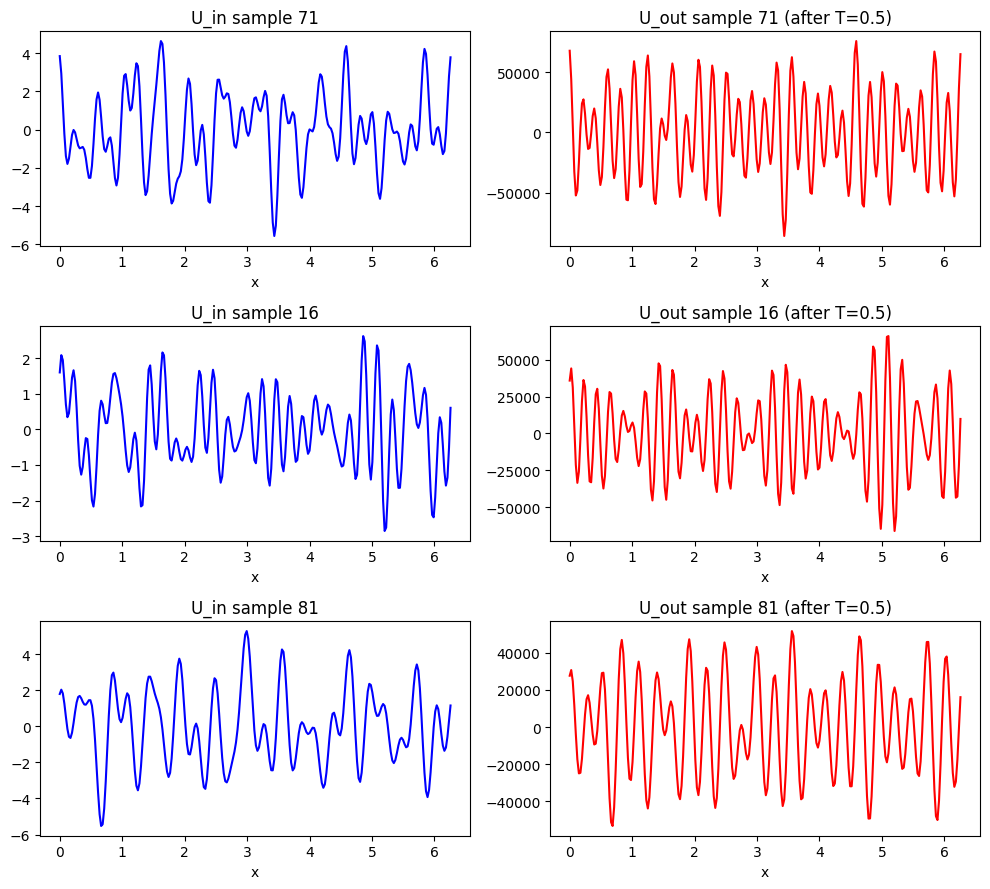

Symbol identification
Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


/home/philippe/anaconda3/envs/psipy/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
/home/philippe/anaconda3/envs/psipy/lib/python3.12/site-packages/pysr/sr.py:2265: UserWarning: Note: you are running with more than 10,000 datapoints. You should consider turning on batching (https://ai.damtp.cam.ac.uk/pysr/options/#batching). You should also reconsider if you need that many datapoints. Unless you have a large amount of noise (in which case you should smooth your dataset first), generally < 10,000 datapoints is enough to find a functional form with symbolic regression. More datapoints will lower the search speed.
  warnings.warn(
/home/philippe/anaconda3/envs/psipy/lib/python3.12/site-packages/pysr/sr.py:1873: UserWarning: Note: Setting `random_state` without also setting `deterministic=True` and `parallelism='serial'` will result in non-deterministic searches.
  warnings.war

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sympy import symbols, lambdify
from matplotlib.gridspec import GridSpec
import matplotlib.pyplot as plt

# Import your custom modules
from pde_data_generator import generate_advection_1d
from symbol_regression import identify_operator, validate_identification
from symbol_estimator import symbol_estimation_diagnostics
# Assume psiop is available (if not, comment out the apply part)
try:
    from psiop import PseudoDifferentialOperator
except ImportError:
    PseudoDifferentialOperator = None
    print("Warning: psiop not found, operator application will be skipped.")

# ============================================================================
# 1. Generate data
# ============================================================================
print("Data generation")
from sympy import symbols, I, sin
x_sym, xi_sym = symbols('x xi', real=True)
T = 0.5
# Define your symbol (e.g., a(x,xi) = - sin(x) * i * xi)
a_expr = xi_sym ** 2

# Generate data
x_grid, xi_grid, U_in, U_out, true_sym = generate_from_symbol(
    a_expr, N_samples=100, Nx=256, L=2*np.pi, seed=42
)

# ============================================================================
# Display the generated data
# ============================================================================

# 1. Plot a few random initial conditions and their outputs
n_plot = 3
indices = np.random.choice(U_in.shape[0], n_plot, replace=False)

fig, axes = plt.subplots(n_plot, 2, figsize=(10, 3*n_plot))
for i, idx in enumerate(indices):
    axes[i, 0].plot(x_grid, U_in[idx], 'b-')
    axes[i, 0].set_title(f'U_in sample {idx}')
    axes[i, 0].set_xlabel('x')
    
    axes[i, 1].plot(x_grid, U_out[idx], 'r-')
    axes[i, 1].set_title(f'U_out sample {idx} (after T={T})')
    axes[i, 1].set_xlabel('x')
plt.tight_layout()
plt.show()


# ============================================================================
# 2. Identify operator symbolically
# ============================================================================
print("Symbol identification")
pysr_options = {
    'constraints': {'^': (-1, 1)},
    'batch_size': 1000,
}

# Use a reasonable window width (default is L/sqrt(Nx)) instead of dx/2
window_width = (x_grid[1] - x_grid[0]) * 4   # optional
op, expr, xi_grid, sym_mat, meta = identify_operator(
    U_in, U_out, x_grid,
    # method='svd',
    method='pysr',
    # pysr_options=pysr_options,
    # window_width = None,
    window_width = window_width,   # uncomment if you want a custom width
    quantization = 'kohn-nirenberg',
)

print("Identified expression:", expr)
print("Method used:", meta['method_used'])

# ============================================================================
# 3. Validate against ground truth (numerical error)
# ============================================================================
print("Validation")
metrics = validate_identification(op, true_sym, x_grid, xi_grid)
print(f"Relative L2 error: {metrics['rel_l2_error']:.2e}")
print(f"Max absolute error: {metrics['max_abs_error']:.2e}")
print(f"Passed (error < 0.15): {metrics['passed']}")

# ============================================================================
# 4. Visualisations
# ============================================================================
# Create meshgrid for plotting
X, XI = np.meshgrid(x_grid, xi_grid, indexing='ij')
a_true = true_sym(X, XI)
a_est = sym_mat   # numerical symbol matrix from estimator

# ---- 4.1 True vs Estimated symbol (real and imaginary parts) ----
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
titles = ['True Re(a)', 'Estimated Re(a)', 'True Im(a)', 'Estimated Im(a)']
data = [a_true.real, a_est.real, a_true.imag, a_est.imag]
for ax, d, title in zip(axes.flat, data, titles):
    im = ax.pcolormesh(x_grid, xi_grid, d.T, shading='auto', cmap='RdBu')
    ax.set_xlabel('x')
    ax.set_ylabel('ξ')
    ax.set_title(title)
    plt.colorbar(im, ax=ax)
plt.suptitle('Symbol comparison: true vs estimated')
plt.tight_layout()
plt.show()

# ---- 4.2 Error maps (absolute and relative) ----
err_abs = np.abs(a_true - a_est)
err_rel = err_abs / (np.abs(a_true) + 1e-10)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
im1 = ax1.pcolormesh(x_grid, xi_grid, err_abs.T, shading='auto', cmap='hot')
ax1.set_title('Absolute error |a_true - a_est|')
ax1.set_xlabel('x'); ax1.set_ylabel('ξ')
plt.colorbar(im1, ax=ax1)

im2 = ax2.pcolormesh(x_grid, xi_grid, err_rel.T, shading='auto', cmap='hot', vmin=0, vmax=0.2)
ax2.set_title('Relative error (clipped at 0.2)')
ax2.set_xlabel('x'); ax2.set_ylabel('ξ')
plt.colorbar(im2, ax=ax2)
plt.suptitle('Symbol estimation errors')
plt.tight_layout()
plt.show()



# ============================================================================
# 4.5 Operator application on a test function (updated for variable c)
# ============================================================================
# ============================================================================
# Helper: apply a symbol to a test function (KN integral)
# ============================================================================
def apply_symbol(u, a_func, x_grid, xi_grid):
    """
    Compute u_out(x) = (1/2π) ∫ a(x, ξ) û(ξ) e^{i x ξ} dξ
    using the given numeric symbol function a_func(x, ξ).
    """
    Nx = len(x_grid)
    dx = x_grid[1] - x_grid[0]
    dxi = xi_grid[1] - xi_grid[0]
    u_hat = np.fft.fft(u)
    u_out = np.zeros(Nx, dtype=complex)
    for i, x in enumerate(x_grid):
        integrand = a_func(x, xi_grid) * u_hat * np.exp(1j * xi_grid * x)
        u_out[i] = np.sum(integrand) * dxi / (2 * np.pi)
    return np.real(u_out)

# ============================================================================
# 4.5 Operator application on a test function (generic version)
# ============================================================================
if PseudoDifferentialOperator is not None:
    # Create the operator from the identified symbol expression
    op_symbolic = PseudoDifferentialOperator(expr, [x_sym], mode='symbol')
    
    # Test function: a sine wave (can be any function)
    u_test = np.sin(x_grid)
    
    # True output: apply the true symbol (from data generator)
    # true_sym is a callable a_true(x, ξ) returned by generate_from_symbol
    u_out_true = apply_symbol(u_test, true_sym, x_grid, xi_grid)
    
    # Estimated output: try op.apply first, fallback to numeric symbol matrix
    try:
        u_out_est = op_symbolic.apply(u_test, x_grid, xi_grid)
    except (AttributeError, NotImplementedError):
        # Fallback: use the estimated numeric symbol matrix sym_mat
        print("Falling back to numeric symbol matrix for estimated output.")
        def a_est_num(x_val, xi_vals):
            # Interpolate the symbol matrix at the given x (nearest neighbour)
            idx = np.argmin(np.abs(x_grid - x_val))
            return sym_mat[idx, :]
        u_out_est = apply_symbol(u_test, a_est_num, x_grid, xi_grid)
    
    plt.figure(figsize=(8,5))
    plt.plot(x_grid, u_test, 'k-', label='Input u_in(x) = sin(x)')
    plt.plot(x_grid, u_out_true, 'b-', label='True u_out (from true symbol)')
    plt.plot(x_grid, u_out_est, 'r--', label='Estimated u_out')
    plt.xlabel('x'); plt.ylabel('u')
    plt.title('Operator validation: applying to a new test function')
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    print("psiop not available – operator application test skipped.")

# ---- 4.6 (Optional) Reconstruction error on training data ----
# This uses the estimator's internal reconstruction (if implemented)
# For completeness, we try to compute the output of the estimated operator
# on the training inputs using the STFT method (approximate).
# Note: This requires the inverse Gabor transform, which is not provided.
# Instead, we can compute the error between true U_out and the output predicted
# by the identified symbol using the same STFT least-squares estimate.
# The function symbol_estimation_diagnostics expects a reconstructed U_out,
# which we do not have directly. We'll skip it for brevity.